# Practice Data Engineering with Python

Fill out the code, as necessary, below based on the directions in Canvas.

In this practice, you will delve into the fundamental stages of the data engineering pipeline in Python, with particular emphasis on the powerful NumPy and Pandas libraries. By constructing a simple yet comprehensive data pipeline for weather data analysis, you will gain hands-on experience in each critical step of the process, from the initial generation of data to its final presentation in a meaningful format.

After going through the code, you will also be required to interpret the code you write and the output it generates, which will involve understanding the purpose and functionality of each line of code, predicting and verifying the output at various stages, and troubleshooting any issues that arise.

By engaging with both the construction and analysis of the data pipeline, you will develop a deeper understanding of how data engineering principles are applied in real-world scenarios, and how Python can be leveraged to handle data efficiently and effectively. This comprehensive approach will equip you with the skills needed to manage data pipelines in more complex projects, preparing you for challenges you may encounter as a data scientist in the industry.

Imagine you're working as a junior data scientist at a retail company that sells a variety of products, including electronics, clothing, and books. The company has been collecting sales data over time and now wants to analyze it to gain insights into sales trends, customer preferences, and overall revenue.

The provided dataset represents a snapshot of sales transactions over 10 days in May 2023. Each transaction records the following details:

Order ID: A unique identifier for each sales transaction.
Order Date: The date on which the transaction took place.
Product ID: A unique identifier for each product sold.
Product Category: The category to which the product belongs, such as Electronics, Clothing, or Books.
Quantity: The number of units of the product sold in that transaction.
Unit Price: The price per unit of the product.
Customer ID: A unique identifier for the customer who made the purchase.
In particular, the code does the following:

Generation: You will start by generating sample weather data in CSV format. This step simulates collecting raw data from weather stations or sensors.
Storage: Once generated, the data will be stored in a local file system. This step describes how data is typically stored in systems such as data lakes or databases, ensuring it is organized and accessible.
Ingestion: In this stage, you will read the stored weather data into a Pandas DataFrame, which mirrors loading data from storage into a data processing environment for further manipulation.
Transformation: Here, you will clean, format, and engineer features from the ingested data. This stage is crucial because it prepares the data for analysis, ensuring it is accurate and consistent and ready to yield insights.
Serving Data: Finally, you will serve the transformed data by creating a simple visualization using Matplotlib. This step illustrates how processed data is often presented to stakeholders in a meaningful way, enabling data-driven decision-making.

In [1]:
# imports 
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Step 1: Generation

sales_data = [
    ['1001', '2023-05-01', 'P001', 'Electronics', 2, 99.99, 'C001'],
    ['1002', '2023-05-02', 'P002', 'Clothing', 1, 29.95, 'C002'],
    ['1003', '2023-05-03', 'P003', 'Books', 3, 14.99, 'C001'],
    ['1004', '2023-05-04', 'P004', 'Electronics', 1, 249.99, 'C003'],
    ['1005', '2023-05-05', 'P005', 'Clothing', 2, 39.95, 'C002'],
    ['1006', '2023-05-06', 'P001', 'Electronics', 1, 99.99, 'C004'],
    ['1007', '2023-05-07', 'P002', 'Clothing', 3, 29.95, 'C001'],
    ['1008', '2023-05-08', 'P003', 'Books', 2, 14.99, 'C003'],
    ['1009', '2023-05-09', 'P004', 'Electronics', 1, 249.99, 'C002'],
    ['1010', '2023-05-10', 'P005', 'Clothing', 1, 39.95, 'C004']
]

with open('sales_data.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['order_id', 'order_date', 'product_id', 'product_category', 'quantity', 'unit_price', 'customer_id'])
    writer.writerows(sales_data)

In [3]:
# Step 2: Storage
# Data is stored in the 'sales_data.csv' file

In [4]:
!ls

dsc_c1w1m6.ipynb sales_data.csv


In [5]:
# Step 3: Ingestion
df = pd.read_csv('sales_data.csv')
print(df.head())
print(df.info())

   order_id  order_date product_id product_category  quantity  unit_price  \
0      1001  2023-05-01       P001      Electronics         2       99.99   
1      1002  2023-05-02       P002         Clothing         1       29.95   
2      1003  2023-05-03       P003            Books         3       14.99   
3      1004  2023-05-04       P004      Electronics         1      249.99   
4      1005  2023-05-05       P005         Clothing         2       39.95   

  customer_id  
0        C001  
1        C002  
2        C001  
3        C003  
4        C002  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          10 non-null     int64  
 1   order_date        10 non-null     object 
 2   product_id        10 non-null     object 
 3   product_category  10 non-null     object 
 4   quantity          10 non-null     int64  
 5   unit_p

In [6]:
# Step 4: Transformation
# Data cleaning
df = df.dropna()
df = df.drop_duplicates()

# Formatting
df['order_date'] = pd.to_datetime(df['order_date'])

# Feature engineering
df['total_revenue'] = df['quantity'] * df['unit_price']

# Data manipulation
grouped = df.groupby('product_category')[['total_revenue', 'quantity']].agg({'total_revenue': 'sum', 'quantity': 'mean'}).reset_index()
print(grouped)


  product_category  total_revenue  quantity
0            Books          74.95      2.50
1         Clothing         239.65      1.75
2      Electronics         799.95      1.25


/var/folders/34/04c81vd50td7pl0_60hq1_6m0000gn/T/ipykernel_4833/2580931001.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='product_category', y='total_revenue', data=grouped, palette='viridis')


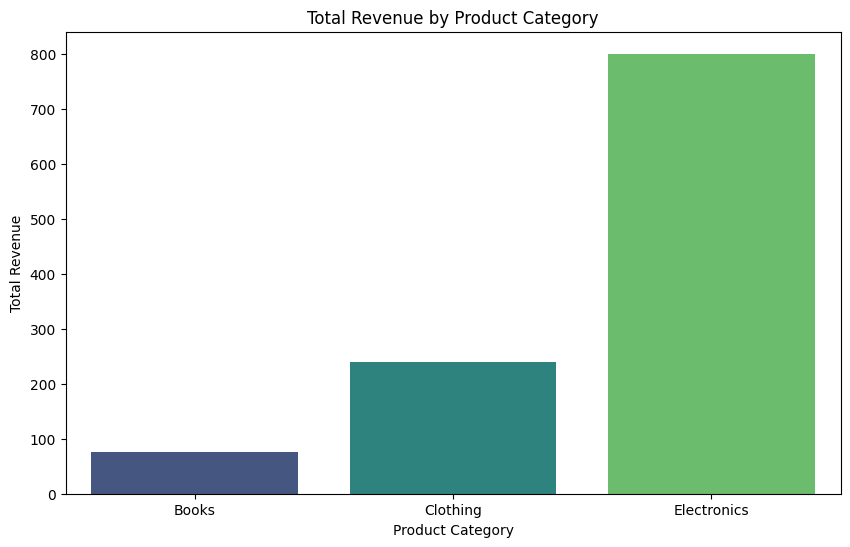

In [7]:
# Step 5: Serving Data
plt.figure(figsize=(10, 6))
sns.barplot(x='product_category', y='total_revenue', data=grouped, palette='viridis')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.title('Total Revenue by Product Category')
plt.show()

1. What is the purpose of the csv.writer function in the code?

__It converts user data into delimited strings and writes them to an object which is returned by the function.__

2. What will be the output of df.head() immediately after the data is ingested?

__The output will be a dataframe of the ingested data.__

3. What does the df.dropna() function do in the data transformation step?

__It deletes records(rows) that have Null values.__

4. What is the significance of the df['order_date'] = pd.to_datetime(df['order_date']) line?

__It converts the values within the order_date column into a datetime object.__

5. What will the grouped DataFrame contain after the groupby operation?

-

6. What will happen if there are duplicate rows in the DataFrame before running the transformation step?

__It will scue the numbers__

7. Which of the following best describes the data visualization created by the code?

__Most of the revenue came from electronics.__

8. What is the purpose of the plt.figure(figsize=(10, 6)) line in the visualization code?

__create a new figure frame and set its dementions to 10x6.__

9. If the grouped DataFrame has missing values for some product categories after aggregation, what could be the reason?

10. What would happen if the total_revenue column were not created before the aggregation step?

__SOLUTION:__ 

1. What is the purpose of the csv.writer function in the code?

_To write data into a CSV file. The csv.writer function writes data to a CSV file, as shown in the code where sales_data is written to sales_data.csv._

2. What will be the output of df.head() immediately after the data is ingested?

_The first five rows of the sales data from the CSV file. df.head() returns the first five rows of the DataFrame created from the CSV file, which contains the sales data._

3. What does the df.dropna() function do in the data transformation step?

_Drops rows with any missing values. df.dropna() removes rows that contain any missing (NaN) values._

4. What is the significance of the df['order_date'] = pd.to_datetime(df['order_date']) line?

_It converts the order_date column from a string to a datetime format. The pd.to_datetime function converts the order_date column from string format to a datetime object, which is essential for date-related operations._

5. What will the grouped DataFrame contain after the groupby operation?

_The sum of total_revenue and the mean of quantity for each product category. The code uses groupby to calculate the sum of total_revenue and the mean of quantity for each product category._

6. What will happen if there are duplicate rows in the DataFrame before running the transformation step?

_The duplicate rows will be automatically removed. The df.drop_duplicates() function is used specifically to remove any duplicate rows in the DataFrame._

7. Which of the following best describes the data visualization created by the code?

_A bar chart showing the total revenue for each product category. The code uses sns.barplot to create a bar chart that visualizes total revenue by product category._

8. What is the purpose of the plt.figure(figsize=(10, 6)) line in the visualization code?

_To set the size of the plot. The figsize parameter sets the dimensions of the plot, in this case, 10 inches wide and 6 inches tall._

9. If the grouped DataFrame has missing values for some product categories after aggregation, what could be the reason?

_The dropna() function removed rows with missing values. If there were missing values in the original data, dropna() would have removed those rows, potentially leading to some categories being excluded in the final grouped DataFrame._

10. What would happen if the total_revenue column were not created before the aggregation step?

_The grouped DataFrame would only contain the quantity column. If total_revenue is not created before the groupby operation, the grouped DataFrame would only include the quantity column, as the aggregation function was not applied to total_revenue._